## NO2 EDA 

##  LOAD DATA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("../../../data/validated/NO2_cityday.csv")  
df = pd.read_csv(DATA_PATH)

print("Raw shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head())

Raw shape: (232952, 5)
Columns: ['City', 'Date', 'NO2_daily', 'Year', 'Month']


,City,Date,NO2_daily,Year,Month
0,Agassiz,2021-01-01,7.208333,2021,1
1,Agassiz,2021-01-02,8.083333,2021,1
2,Agassiz,2021-01-03,11.916667,2021,1
3,Agassiz,2021-01-04,9.583333,2021,1
4,Agassiz,2021-01-05,12.750000,2021,1


## STANDARDIZE COLUMNS

In [3]:
df.columns = df.columns.str.strip()

In [4]:
NO2_COL = "NO2_daily"  
if NO2_COL not in df.columns:
    raise ValueError(f"Expected NO2 column '{NO2_COL}' not found. Available: {df.columns.tolist()}")

if "Date" not in df.columns:
    raise ValueError(f"'Date' column not found. Available: {df.columns.tolist()}")

if "City" not in df.columns:
    raise ValueError(f"'City' column not found. Available: {df.columns.tolist()}")


In [5]:
df["Date"] = df["Date"].astype(str).str.strip()


## ROBUST DATE PARSING 

In [6]:

d1 = pd.to_datetime(df["Date"], errors="coerce", infer_datetime_format=True)

mask = d1.isna()
d2 = pd.to_datetime(df.loc[mask, "Date"], errors="coerce", dayfirst=True, infer_datetime_format=True)

df["Date_parsed"] = d1
df.loc[mask, "Date_parsed"] = d2

df = df.dropna(subset=["Date_parsed"]).copy()
df = df.drop(columns=["Date"])
df = df.rename(columns={"Date_parsed": "Date"})

C:\Users\Jaya\AppData\Local\Temp\ipykernel_10228\1680124182.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  d1 = pd.to_datetime(df["Date"], errors="coerce", infer_datetime_format=True)
C:\Users\Jaya\AppData\Local\Temp\ipykernel_10228\1680124182.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  d2 = pd.to_datetime(df.loc[mask, "Date"], errors="coerce", dayfirst=True, infer_datetime_format=True)


## REMOVE IMPOSSIBLE FUTURE/PAST DATES

In [7]:

start_date = pd.Timestamp("2020-01-01")
end_date   = pd.Timestamp("2023-12-31")

df = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()

## REBUILD TIME FEATURES CORRECTLY

In [8]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

def season_from_month(m):
    if m in (12, 1, 2): return "Winter"
    if m in (3, 4, 5): return "Spring"
    if m in (6, 7, 8): return "Summer"
    return "Fall"

df["Season"] = df["Month"].apply(season_from_month)

## BASIC QUALITY CHECKS + CLEAN DUPLICATES

In [9]:
df = df.sort_values(["City", "Date"])
dup = df.duplicated(subset=["City", "Date"]).sum()
if dup > 0:
    df = df.drop_duplicates(subset=["City", "Date"], keep="first")


In [10]:
print("Rows:", df.shape[0], "| Cols:", df.shape[1])
print("Date range:", df["Date"].min(), "→", df["Date"].max())
print("Unique cities:", df["City"].nunique())
print("Missing NO2:", df[NO2_COL].isna().sum())
display(df.head(5))

Rows: 163962 | Cols: 6
Date range: 2020-02-18 00:00:00 → 2023-12-31 00:00:00
Unique cities: 155
Missing NO2: 0


,City,NO2_daily,Year,Month,Date,Season
0,Agassiz,7.208333,2021,1,2021-01-01,Winter
1,Agassiz,8.083333,2021,1,2021-01-02,Winter
2,Agassiz,11.916667,2021,1,2021-01-03,Winter
3,Agassiz,9.583333,2021,1,2021-01-04,Winter
4,Agassiz,12.750000,2021,1,2021-01-05,Winter


In [11]:
print("NO2 Summary Statistics")
display(df["NO2_daily"].describe())

NO2 Summary Statistics


count    163962.000000
mean          5.251502
std           4.833274
min           0.000000
25%           1.875000
50%           3.833333
75%           7.086957
max          49.347826
Name: NO2_daily, dtype: float64

The summary statistics provide an overview of NO₂ concentration levels across the dataset. The mean value represents the average daily NO₂ concentration across all cities and time periods. The minimum and maximum values indicate the range of observed pollution levels. The standard deviation reflects the variability in NO₂ concentrations across observations.

## NO₂ Distribution Histogram

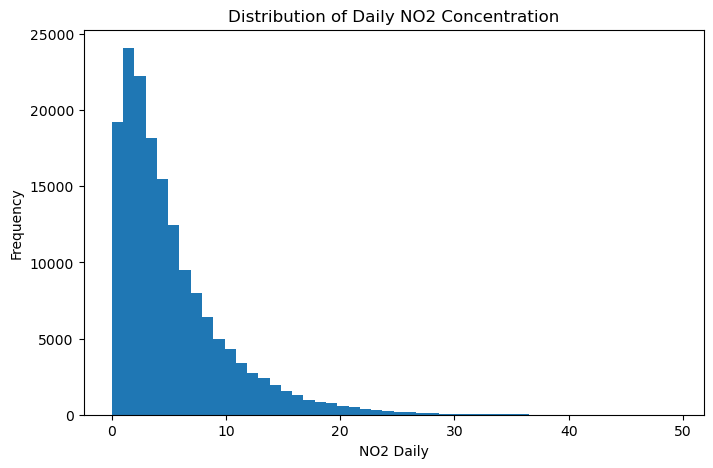

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["NO2_daily"], bins=50)
plt.title("Distribution of Daily NO2 Concentration")
plt.xlabel("NO2 Daily")
plt.ylabel("Frequency")
plt.show()

The histogram illustrates the distribution of daily NO₂ concentrations. Most observations appear clustered within the lower concentration range, indicating that extremely high pollution levels are relatively rare. This visualization helps identify skewness and potential outliers in the dataset.

## Yearly NO₂ Trend

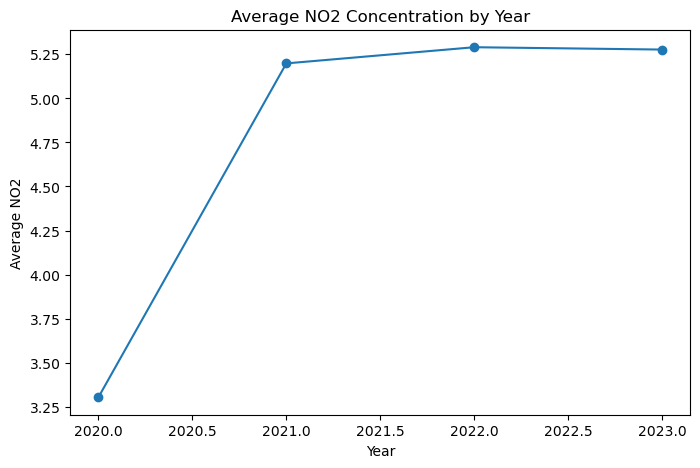

In [13]:
yearly_no2 = df.groupby("Year")["NO2_daily"].mean()

plt.figure(figsize=(8,5))
plt.plot(yearly_no2.index, yearly_no2.values, marker='o')
plt.title("Average NO2 Concentration by Year")
plt.xlabel("Year")
plt.ylabel("Average NO2")
plt.show()

The yearly trend visualization illustrates how average NO₂ concentrations have evolved over time. Observing year-to-year variations helps identify long-term pollution trends and potential improvements or deteriorations in air quality.

## Monthly Seasonality

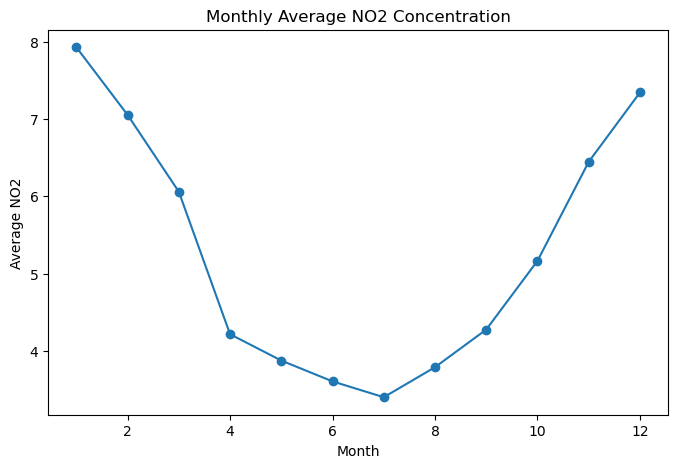

In [14]:
monthly_no2 = df.groupby("Month")["NO2_daily"].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly_no2.index, monthly_no2.values, marker='o')
plt.title("Monthly Average NO2 Concentration")
plt.xlabel("Month")
plt.ylabel("Average NO2")
plt.show()

Monthly analysis helps reveal seasonal patterns in air pollution. Variations across months may reflect differences in weather conditions, industrial activity, and transportation patterns that influence NO₂ emissions.

## Top 10 Most Polluted Cities (NO₂)

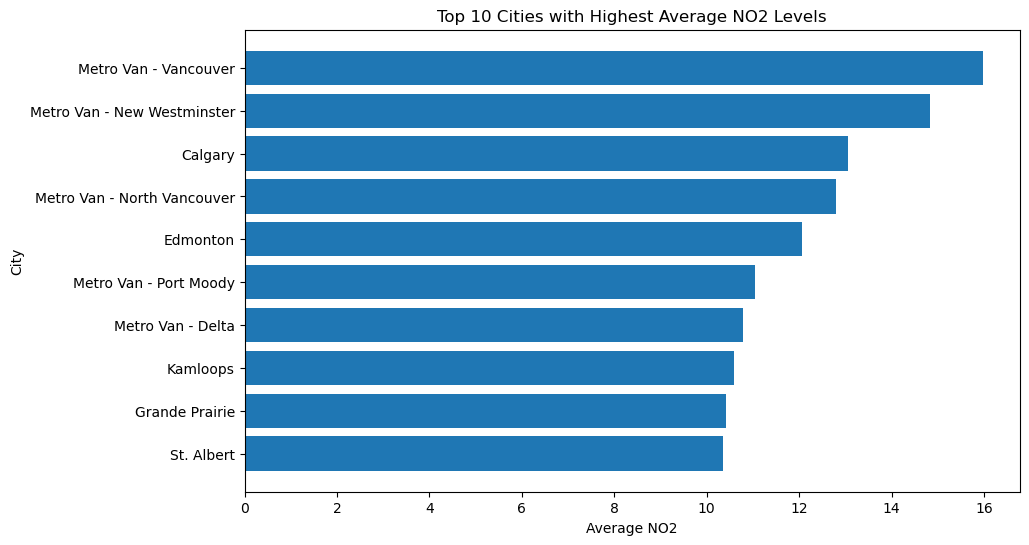

In [15]:
city_avg = df.groupby("City")["NO2_daily"].mean().sort_values(ascending=False)

top10 = city_avg.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10.index, top10.values)
plt.title("Top 10 Cities with Highest Average NO2 Levels")
plt.xlabel("Average NO2")
plt.ylabel("City")
plt.gca().invert_yaxis()
plt.show()

The city-level analysis identifies locations with the highest average NO₂ concentrations. These cities may experience higher traffic density, industrial emissions, or urban congestion, which contribute to elevated pollution levels.

## Seasonal Boxplot

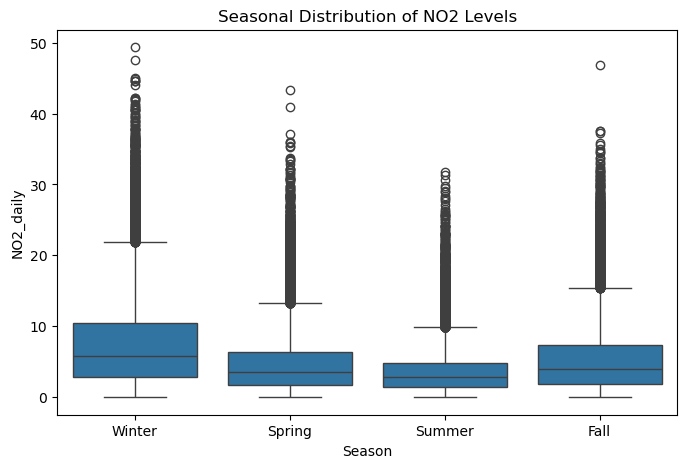

In [16]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x="Season", y="NO2_daily", data=df)
plt.title("Seasonal Distribution of NO2 Levels")
plt.show()

The seasonal boxplot highlights how NO₂ concentrations vary across seasons. Differences between seasons may reflect meteorological conditions such as temperature, wind patterns, and atmospheric stability that influence pollutant dispersion.

In [17]:
pm25 = pd.read_csv("../../../data/validated/PM25_cityday.csv")

pm25.columns = pm25.columns.str.strip()

pm25["Date"] = pd.to_datetime(pm25["Date"], errors="coerce")

pm25 = pm25.dropna(subset=["Date"])

pm25 = pm25[(pm25["Date"] >= "2020-01-01") & (pm25["Date"] <= "2023-12-31")]

pm25.head()

,City,Date,PM25_daily,Year,Month
0,MontrÃ©al,2020-01-01,4.333333,2020,1
1,MontrÃ©al,2020-01-02,7.625000,2020,1
2,MontrÃ©al,2020-01-03,10.750000,2020,1
3,MontrÃ©al,2020-01-04,4.416667,2020,1
4,MontrÃ©al,2020-01-05,3.833333,2020,1


In [18]:
pm25 = pm25[["City","Date","PM25_daily"]]

In [19]:
no2 = df[["City","Date","NO2_daily"]]

In [20]:
merged = pd.merge(pm25, no2, on=["City","Date"], how="inner")

print("Merged dataset size:", merged.shape)

merged.head()

Merged dataset size: (151711, 4)


,City,Date,PM25_daily,NO2_daily
0,St. John's,2020-02-18,5.541667,2.416667
1,St. John's,2020-02-19,4.708333,1.875000
2,St. John's,2020-02-20,5.583333,0.958333
3,St. John's,2020-02-21,4.750000,0.750000
4,St. John's,2020-02-22,5.791667,1.500000


In [21]:
print("Unique cities:", merged["City"].nunique())

print("Date range:", merged["Date"].min(), "to", merged["Date"].max())

Unique cities: 145
Date range: 2020-02-18 00:00:00 to 2023-12-31 00:00:00


## Scatter plot (PM2.5 vs NO₂)

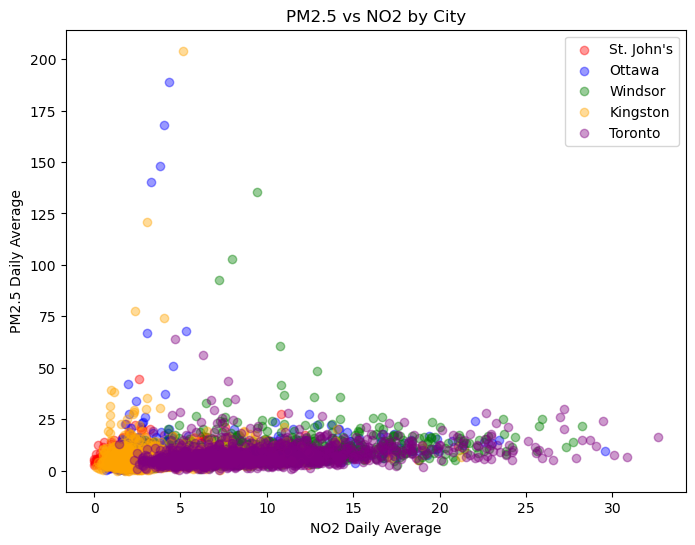

In [22]:
plt.figure(figsize=(8,6))

cities = merged["City"].unique()[:5]

colors = ["red","blue","green","orange","purple"]

for city, color in zip(cities, colors):

    temp = merged[merged["City"] == city]

    plt.scatter(
        temp["NO2_daily"],
        temp["PM25_daily"],
        color=color,
        alpha=0.4,
        label=city
    )

plt.xlabel("NO2 Daily Average")
plt.ylabel("PM2.5 Daily Average")
plt.title("PM2.5 vs NO2 by City")

plt.legend()
plt.show()

The scatter plot shows the relationship between NO₂ and PM2.5 concentrations across multiple cities. A generally positive trend can be observed, indicating that higher NO₂ levels are often associated with increased PM2.5 concentrations. This pattern likely reflects shared emission sources such as traffic and industrial activity. However, the wide dispersion of points suggests that additional factors, including weather conditions and local environmental characteristics, also influence particulate pollution levels.

## Correlation analysis

In [23]:
corr = merged[["PM25_daily","NO2_daily"]].corr()

print("Correlation Matrix:")
corr

Correlation Matrix:


,PM25_daily,NO2_daily
PM25_daily,1.000000,0.116643
NO2_daily,0.116643,1.000000


## City-wise correlation between PM2.5 and NO2

In [24]:
city_corr = (
    merged.groupby("City")
    .apply(lambda g: g["PM25_daily"].corr(g["NO2_daily"]))
    .reset_index(name="Correlation")
)

city_corr = city_corr.dropna().sort_values("Correlation", ascending=False)

city_corr.head(10)

C:\Users\Jaya\AppData\Local\Temp\ipykernel_10228\336990914.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["PM25_daily"].corr(g["NO2_daily"]))


,City,Correlation
140,Whitehorse,0.773574
24,Courtenay,0.664671
64,Laval,0.640187
109,Saint John,0.625111
117,Smithers,0.566022
136,Victoria,0.556969
42,Fredericton,0.542375
12,Buffalo Narrows,0.532754
74,Metro Van - North Vancouver,0.529898
83,Metro Van-Pitt Meadows,0.528455


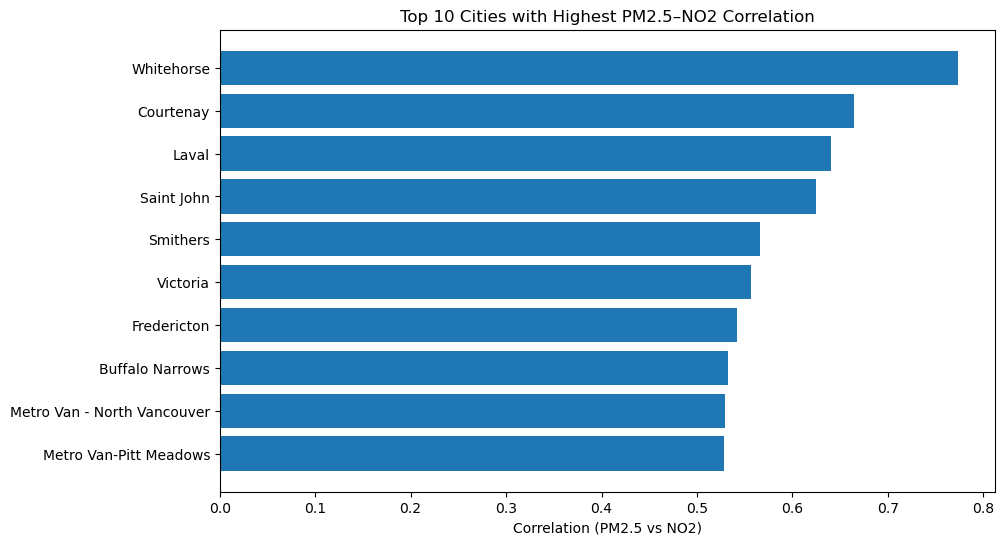

In [25]:
import matplotlib.pyplot as plt

top10 = city_corr.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["City"], top10["Correlation"])

plt.xlabel("Correlation (PM2.5 vs NO2)")
plt.title("Top 10 Cities with Highest PM2.5–NO2 Correlation")

plt.gca().invert_yaxis()

plt.show()

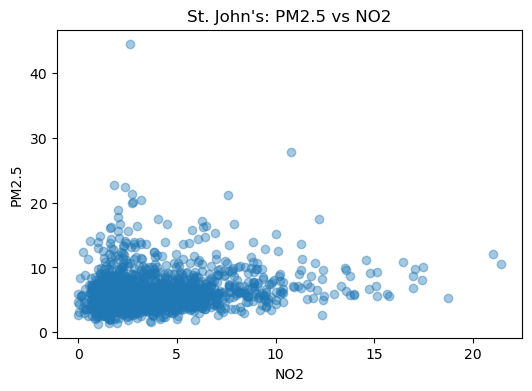

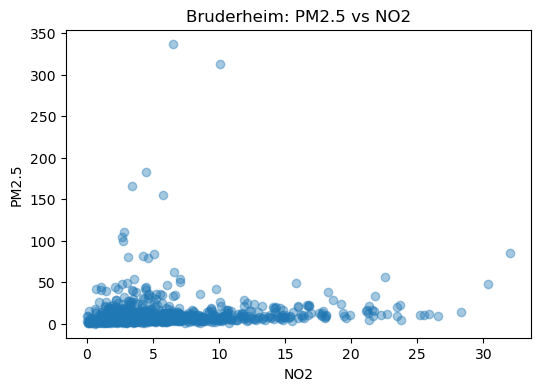

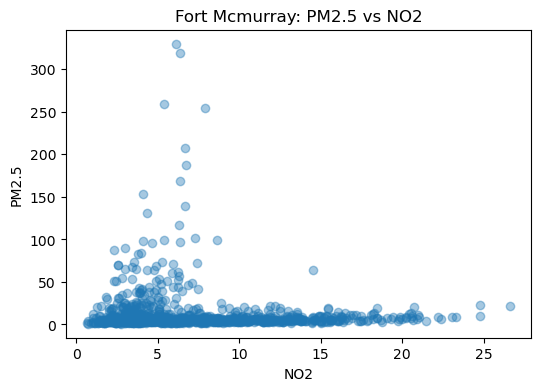

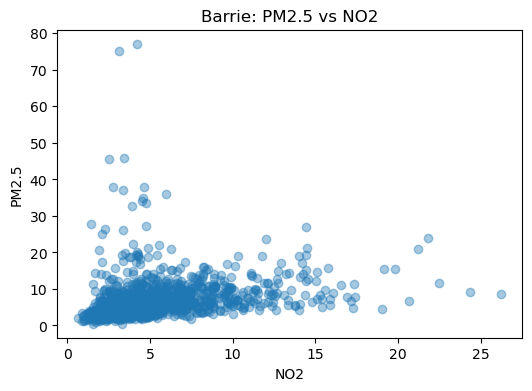

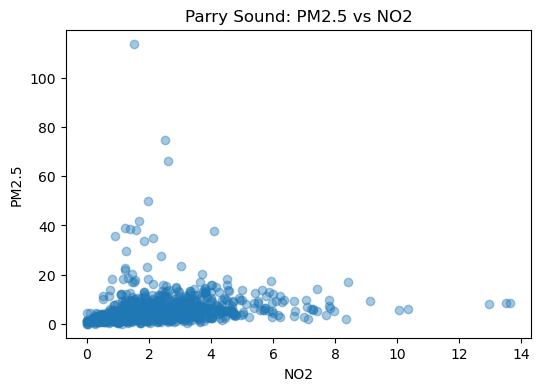

In [26]:
top5 = merged["City"].value_counts().head(5).index

for city in top5:

    data = merged[merged["City"] == city]

    plt.figure(figsize=(6,4))

    plt.scatter(
        data["NO2_daily"],
        data["PM25_daily"],
        alpha=0.4
    )

    plt.title(f"{city}: PM2.5 vs NO2")
    plt.xlabel("NO2")
    plt.ylabel("PM2.5")

    plt.show()